In [1]:
using CMPSExcitations

In [10]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hsingle_cll(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

In [56]:
c, μ = 10., 5.
tol = 1e-10
Ds = [4, 8]
D = maximum(Ds)

HLL = Hsingle_ll(c, μ)
stateLL = find_groundstate(Ds, HLL, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

Optimizing D=4


┌ Info: UniformCMPS ground state: initialization with e = 662.639827905301
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 132 iterations: f = -2.734747817523, ‖∇f‖ = 9.3044e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 4 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  0.113100 seconds (531.85 k allocations: 22.751 MiB, 5.02% gc time)
---------------
Optimizing D=8


┌ Info: UniformCMPS ground state: converged after 133 iterations: e = -2.734747817523, ‖∇e‖ = 9.3044e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127
┌ Info: UniformCMPS ground state: initialization with e = -2.734747817454
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 345 iterations: f = -2.761265509087, ‖∇f‖ = 5.6894e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  3.770869 seconds (3.41 M allocations: 314.329 MiB, 0.78% gc time)
---------------
Energy density: -2.761265509086959
 Particle density: 0.8729544307602687
 Order parameter: -0.511577282909337


┌ Info: UniformCMPS ground state: converged after 346 iterations: e = -2.761265509087, ‖∇e‖ = 5.6894e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127


In [57]:
HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1] / sqrt(2), stateLL.Rs[1] / sqrt(2)));
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Energy density: -2.76126550908697
 Particle density: 0.43647721538013556
 Order parameter: -0.3617397658461814


In [85]:
# HCLLeq = Hcoupled(c, μ)
# stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1] / sqrt(2), stateLL.Rs[1] / sqrt(2)));
# println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

HCLLeq = Hsingle_cll(c, μ)
stateCLLeq = find_groundstate(Ds, HCLLeq, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HCLLeq.h, stateCLLeq)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLLeq)[], "\n Order parameter: ", expval(ψ̂, stateCLLeq)[])

Optimizing D=4


┌ Info: YangGaudinCMPS ground state: initialization with e = 857.521365677717
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 186 iterations: f = -2.734747817523, ‖∇f‖ = 3.8149e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 4 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  0.181714 seconds (822.72 k allocations: 37.912 MiB, 3.39% gc time)
---------------
Optimizing D=8


┌ Info: YangGaudinCMPS ground state: converged after 187 iterations: e = -2.734747817523, ‖∇e‖ = 3.8149e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118
┌ Info: YangGaudinCMPS ground state: initialization with e = -2.734747817514
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 364 iterations: f = -2.761265509087, ‖∇f‖ = 6.0745e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  3.998697 seconds (3.64 M allocations: 335.602 MiB, 0.72% gc time)
---------------
Energy density: -2.7612655090869094
 Particle density: 0.4364772153802628
 Order parameter: -0.3617397658477056


┌ Info: YangGaudinCMPS ground state: converged after 365 iterations: e = -2.761265509087, ‖∇e‖ = 6.0745e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


In [99]:
Q = stateCLLeq.Q[]
R = stateCLLeq.Rs[1][]
U = eigen(rightenv(stateCLLeq)[1][]).vectors
println(eigen(rightenv(stateCLLeq)[1][]).values)

QCLLeq = U \ Q * U
RCLLeq = U \ R * U

[1.8742470282901242e-5, 5.888040864195607e-5, 0.0002378778301126234, 0.001543409766943657, 0.00267812955160048, 0.02098147550475081, 0.1593387070958468, 0.9869961191468863]


8×8 Matrix{Float64}:
 -0.261541  -0.169013   -0.0615951   0.0403976  …   0.00442266    0.000825746
  0.299566   0.299128    0.115868    0.0413388     -0.000857989   0.00873781
  0.219437   0.232891   -0.215729   -0.22425       -0.0405453    -0.000724789
  0.366592  -0.211647    0.571211    0.279009      -0.0208285    -0.0408231
 -0.023395   0.223977   -0.363198   -0.313292      -0.147972      0.0097222
 -1.15673   -0.0707694  -0.532027   -0.42528    …  -0.107343      0.131086
  0.407785   0.0446331   1.04936    -0.21163        0.244818      0.335181
 -0.189492   1.13129    -0.0466866   1.03234       -0.834212     -0.477658

In [100]:
Q = stateCLL.Q[]
R = stateCLL.Rs[1][]
U = eigen(rightenv(stateCLL)[1][]).vectors
println(eigen(rightenv(stateCLL)[1][]).values)
QCLL = U \ Q * U
RCLL = U \ R * U

[1.874247029242528e-5, 5.8880408661516606e-5, 0.0002378778301851996, 0.0015434097671470338, 0.002678129551815604, 0.020981475505892893, 0.1593387070965995, 0.9869961191467395]


8×8 Matrix{Float64}:
 -0.261541  -0.169013    0.0615951  -0.0403976  …  -0.00442266   -0.000825746
  0.299566   0.299128   -0.115868   -0.0413388      0.000857989  -0.00873781
 -0.219437  -0.232891   -0.215729   -0.22425       -0.0405453    -0.000724789
 -0.366592   0.211647    0.571211    0.279009      -0.0208285    -0.0408231
  0.023395  -0.223977   -0.363198   -0.313292      -0.147972      0.0097222
  1.15673    0.0707694  -0.532027   -0.42528    …  -0.107343      0.131086
 -0.407785  -0.0446331   1.04936    -0.21163        0.244818      0.335181
  0.189492  -1.13129    -0.0466866   1.03234       -0.834212     -0.477658

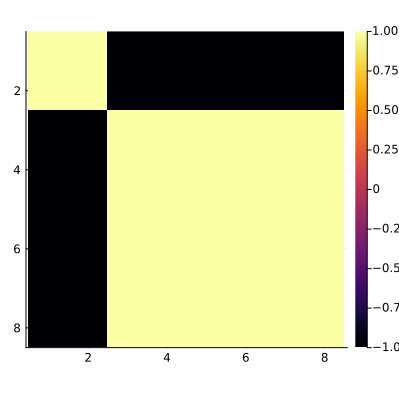

In [ ]:
heatmap(RCLL ./ RCLLeq, yflip=true, aspect_ratio=1, size=(400, 400))

Same upto gauge degree of freedom which is fixed by diagonalizing the right environment.